In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Carregando o dataset
df_exames =pd.read_csv('dataset\diabetes.csv')
df_exames.head()

,id_paciente,genero,idade,peso,altura,resultado
0,1,M,46,83,165,98
1,2,F,23,83,164,82
2,3,M,39,71,154,93
3,4,F,26,103,165,95
4,5,M,27,55,176,100


In [4]:
df_exames.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id_paciente  100 non-null    int64 
 1   genero       100 non-null    object
 2   idade        100 non-null    int64 
 3   peso         100 non-null    int64 
 4   altura       100 non-null    int64 
 5   resultado    100 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 4.8+ KB


In [5]:
df_exames['genero'].unique()

array(['M', 'F'], dtype=object)

In [6]:
# Remover coluna idpaciente

df_exames.drop('id_paciente', axis=1, inplace=True)

In [7]:
df_exames.head()

,genero,idade,peso,altura,resultado
0,M,46,83,165,98
1,F,23,83,164,82
2,M,39,71,154,93
3,F,26,103,165,95
4,M,27,55,176,100


In [8]:
# Converter uma variavel categorica em numerica, usando One Hot Encoding

df_exames = pd.get_dummies(df_exames, columns=['genero'], dtype= 'int64' )

In [9]:
df_exames.head()
df_exames.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   idade      100 non-null    int64
 1   peso       100 non-null    int64
 2   altura     100 non-null    int64
 3   resultado  100 non-null    int64
 4   genero_F   100 non-null    int64
 5   genero_M   100 non-null    int64
dtypes: int64(6)
memory usage: 4.8 KB


<AxesSubplot:>

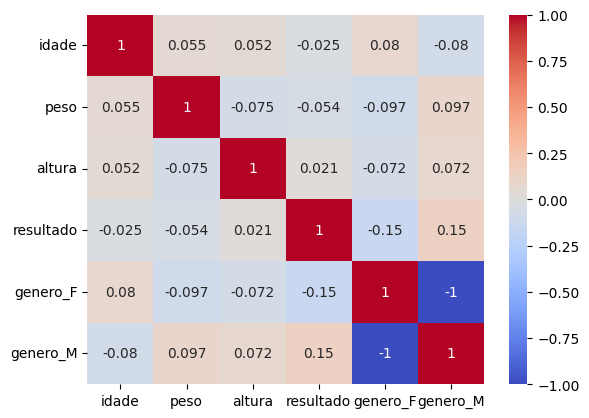

In [10]:
# Apresentar o mapa de calor com correlação entre as variaveis

sns.heatmap(df_exames.corr(), annot=True, cmap='coolwarm')

<AxesSubplot:>

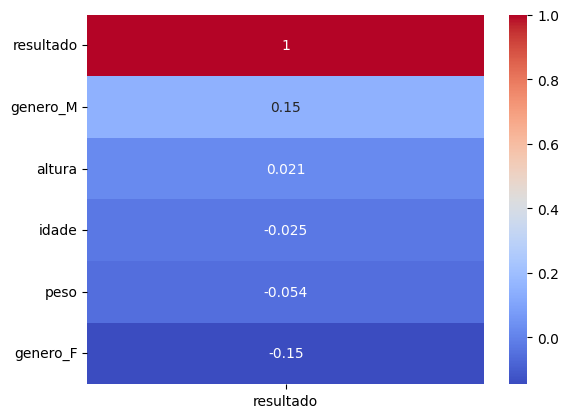

In [11]:
# Mapa de calor so com a variavel target (resultado)

sns.heatmap(df_exames.corr()[['resultado']].sort_values(by = 'resultado', ascending= False), annot=True, cmap='coolwarm', )

array([[<AxesSubplot:xlabel='idade', ylabel='idade'>,
        <AxesSubplot:xlabel='peso', ylabel='idade'>,
        <AxesSubplot:xlabel='altura', ylabel='idade'>,
        <AxesSubplot:xlabel='resultado', ylabel='idade'>,
        <AxesSubplot:xlabel='genero_F', ylabel='idade'>,
        <AxesSubplot:xlabel='genero_M', ylabel='idade'>],
       [<AxesSubplot:xlabel='idade', ylabel='peso'>,
        <AxesSubplot:xlabel='peso', ylabel='peso'>,
        <AxesSubplot:xlabel='altura', ylabel='peso'>,
        <AxesSubplot:xlabel='resultado', ylabel='peso'>,
        <AxesSubplot:xlabel='genero_F', ylabel='peso'>,
        <AxesSubplot:xlabel='genero_M', ylabel='peso'>],
       [<AxesSubplot:xlabel='idade', ylabel='altura'>,
        <AxesSubplot:xlabel='peso', ylabel='altura'>,
        <AxesSubplot:xlabel='altura', ylabel='altura'>,
        <AxesSubplot:xlabel='resultado', ylabel='altura'>,
        <AxesSubplot:xlabel='genero_F', ylabel='altura'>,
        <AxesSubplot:xlabel='genero_M', ylabel='altura

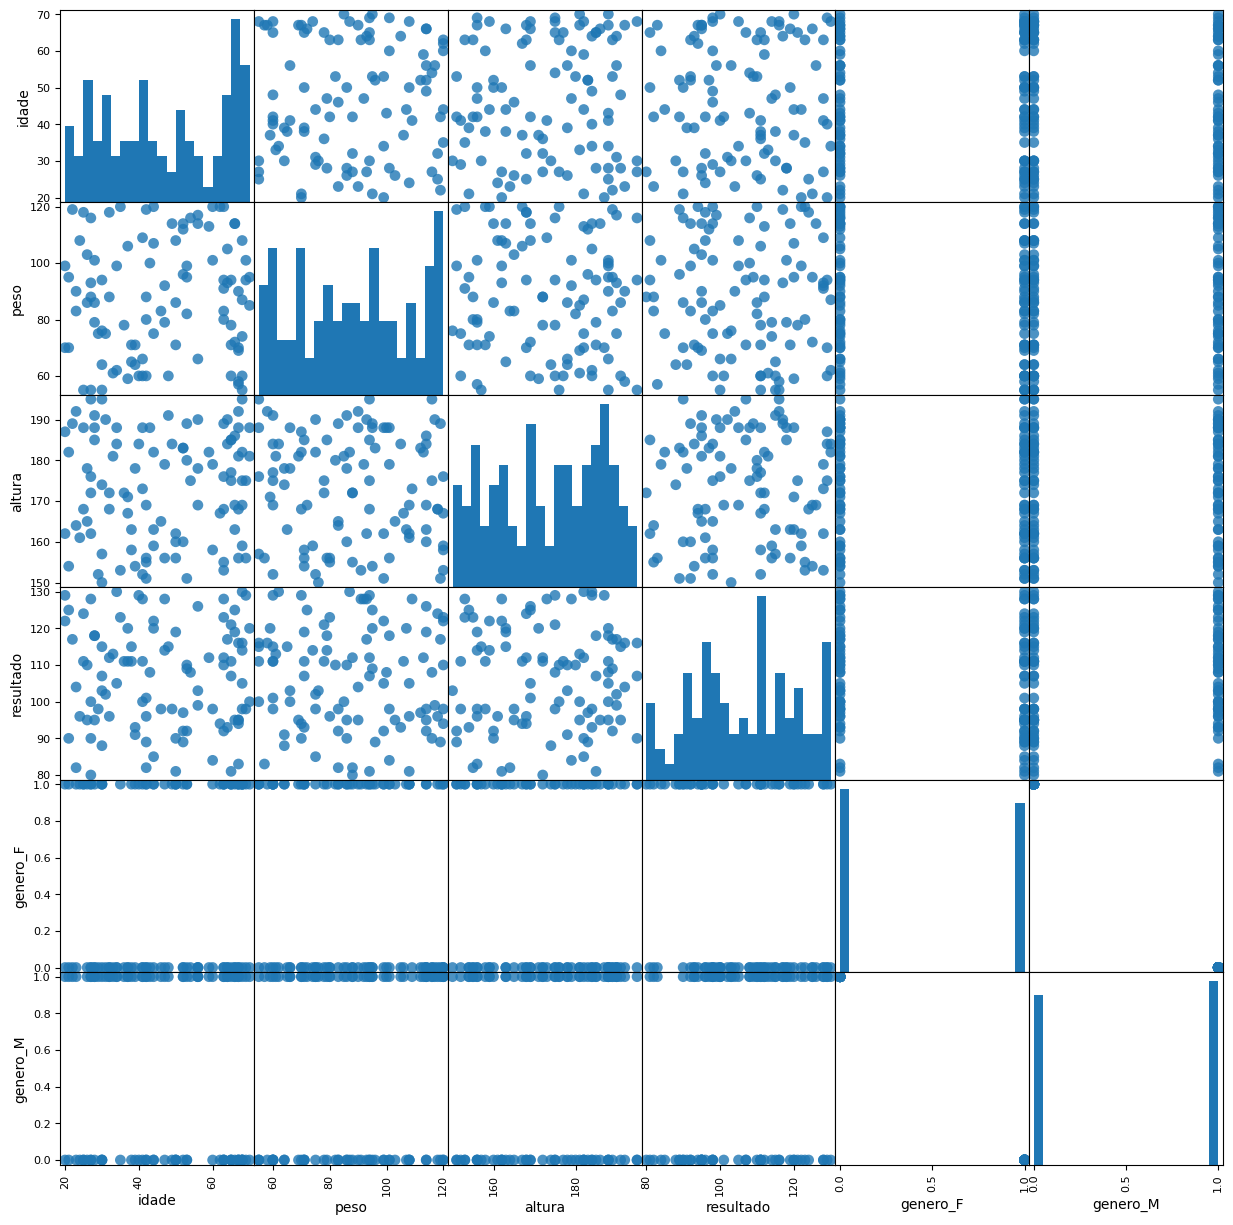

In [12]:
# Plot de Scatter( Dispersão) com distribuição

pd.plotting.scatter_matrix(df_exames, figsize=(15,15), marker='o', hist_kwds={'bins':20}, s=60, alpha=0.8)


array([[<AxesSubplot:title={'center':'idade'}>,
        <AxesSubplot:title={'center':'peso'}>,
        <AxesSubplot:title={'center':'altura'}>],
       [<AxesSubplot:title={'center':'resultado'}>,
        <AxesSubplot:title={'center':'genero_F'}>,
        <AxesSubplot:title={'center':'genero_M'}>]], dtype=object)

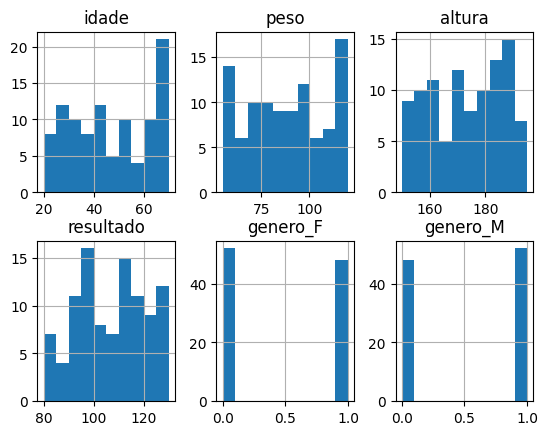

In [13]:
# Histograma de todas as variaveis

df_exames.hist(layout =(2,3))

In [14]:
#Criar uma feature nova (IMC)

df_exames['IMC'] = df_exames['peso'] / ((df_exames['altura']/100)**2)

In [15]:
df_exames.head()

,idade,peso,altura,resultado,genero_F,genero_M,IMC
0,46,83,165,98,0,1,30.486685
1,23,83,164,82,1,0,30.859607
2,39,71,154,93,0,1,29.937595
3,26,103,165,95,1,0,37.832874
4,27,55,176,100,0,1,17.755682


In [16]:
dict_regres = {'tempo_casa': [1,3, 6, 7, 8, 14, 18],'salario': [1200, 2800, 3700, 5200, 7800, 9900, 15000]}

df_regressao_simples = pd.DataFrame(dict_regres)

In [17]:
df_regressao_simples.head()

,tempo_casa,salario
0,1,1200
1,3,2800
2,6,3700
3,7,5200
4,8,7800


<AxesSubplot:xlabel='tempo_casa', ylabel='salario'>

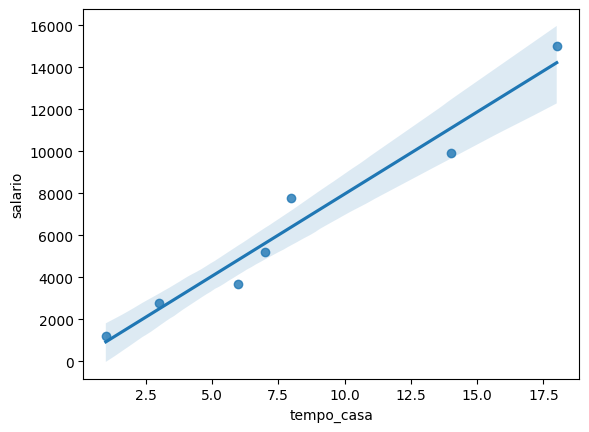

In [18]:
sns.regplot( data = df_regressao_simples, x='tempo_casa', y='salario')

In [19]:
# importar bibliotecas no scikit-learn

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score


In [20]:
# Modelo 1 - Sem IMC

x =df_exames.drop(columns = ['resultado', 'IMC'])
y = df_exames['resultado']

In [21]:
# Dividir o conjunto de dados em treino e teste

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [22]:
len(x_train), len(x_test)

(70, 30)

In [23]:
# Treinar o algoritmo de regressão linear - Modelo 1

model_1 = LinearRegression().fit(x_train, y_train)



In [24]:
# Gerar Predições do conjunto de teste com base no modelo 1

y_pred = model_1.predict(x_test)

In [25]:
y_pred

array([109.53843644, 109.06836921, 103.98171868, 104.1843919 ,
       109.33142279, 104.37079472, 108.59092886, 110.13727517,
       110.71104204, 110.20449926, 110.10771993, 109.54701756,
       102.60866308, 108.6400846 , 109.72842009, 109.38672985,
       103.92092242, 104.35650713, 102.81668613, 103.29145624,
       111.10235508, 104.38561087, 110.1960878 , 104.05544005,
       109.64010565, 103.52146861, 109.05080044, 104.52624598,
       104.36369099, 109.41003404])

In [26]:
# Equação da reta - Regressão Linear
# y = ax + b

model_1.coef_

array([ 0.03090395, -0.0037981 , -0.030631  , -3.07033188,  3.07033188])

In [27]:
model_1.intercept_

111.08194340666552

In [28]:
# R2 Score -Conjunto de treino

model_1.score(x_train, y_train)

0.0449578867292838

In [29]:
# R2 Score - Conjunto de teste

r2_score(y_test, y_pred)

-0.13658613297428324

In [30]:
# R2 Score -  Testes
r2_score(y_test, y_pred)

-0.13658613297428324

In [31]:
# Mean Absolute Error - Testes

mean_absolute_error(y_test, y_pred)

10.523662075022

In [61]:
# Segundo modelo - Apenas IMC

X = pd.DataFrame(df_exames['IMC'])
Y = df_exames['resultado']

# Dividir o conjunto de dados em treino e teste

x_train2, x_test2, y_train2, y_test2 = train_test_split(X,Y, test_size=0.3, random_state=42)

X

,IMC
0,30.486685
1,30.859607
2,29.937595
3,37.832874
4,17.755682
...,...
95,28.666129
96,37.813802
97,40.057345
98,36.419526


In [62]:
# Treinar o algoritmo de regressão linear - Modelo 2
model_2 = LinearRegression().fit(x_train2, y_train2)


In [64]:
# Gerar Predições do conjunto de teste com base no modelo 2 

y_pred2 = model_2.predict(x_test2)

In [65]:
y_pred2

array([106.90620538, 106.80132125, 106.64742151, 107.59559026,
       106.21521895, 106.26591025, 107.12184433, 106.76837589,
       108.0136382 , 106.95098258, 107.07036158, 107.63524533,
       106.60248985, 106.58396459, 107.12970615, 106.18154447,
       107.09996871, 107.70893918, 106.04892254, 107.38832641,
       106.87750848, 107.07037878, 107.14989009, 106.73292137,
       106.7157764 , 106.32924246, 106.50348997, 107.39381987,
       106.64774648, 106.23702222])

In [66]:
model_2.coef_

array([0.06043814])

In [67]:
model_2.intercept_

105.10842415677135

In [70]:
# R2 Score - Conjunto de treino

model_2.score(x_train2, y_train2)

0.0012928972156167617

In [71]:
model_2.score(x_test2, y_test2)

-0.05667934120992646

In [72]:
# MAE (Mean Absolute Error) - Testes

mean_absolute_error(y_test2, y_pred2)

9.906676504559353

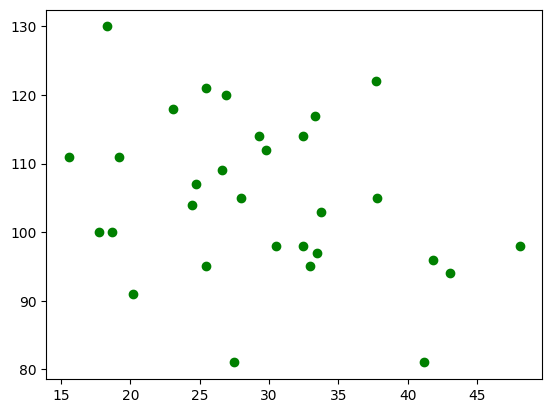

In [75]:
# Mostrar como a reta foi calculada

plt.scatter(x_test, y_test, color='g')

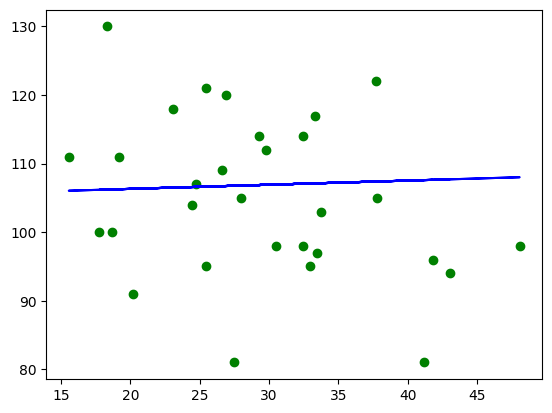

In [78]:
plt.scatter(x_test2, y_test2, color='g')
plt.plot(x_test2, y_pred2, color='b')